In [1]:
# Importing directory 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import os

os.chdir(r"C:\Users\16124\OneDrive\Desktop\Project folder 6")
print(os.getcwd())

C:\Users\16124\OneDrive\Desktop\Project folder 6


In [2]:
# Loading data 
prepared_path = "data/prepared/"
viz_path = "visualizations/"

df = pd.read_csv(prepared_path + "cdi_overall_wide.csv")

print("Shape:", df.shape)
print(df.head())

Shape: (450, 6)
  LocationAbbr LocationDesc  YearStart  diabetes_prevalence  \
0           AK       Alaska       2011                 8.20   
1           AK       Alaska       2012                 7.15   
2           AK       Alaska       2013                 7.20   
3           AK       Alaska       2014                 7.55   
4           AK       Alaska       2015                 7.70   

   inactivity_prevalence  obesity_prevalence  
0                  22.10               27.50  
1                  18.65               25.70  
2                  22.50               28.55  
3                  19.20               29.75  
4                  22.10               30.05  


In [3]:
print("Year range:", df['YearStart'].min(), "to", df['YearStart'].max())
print(df['YearStart'].value_counts().sort_index())

Year range: 2011 to 2021
YearStart
2011    41
2012    41
2013    41
2014    41
2015    41
2016    41
2017    41
2018    41
2019    40
2020    41
2021    41
Name: count, dtype: int64


In [4]:
# creating cluster from 2019-2021 
df_cluster = df[df['YearStart'].isin([2019, 2020, 2021])].dropna(
    subset=['diabetes_prevalence', 'obesity_prevalence', 'inactivity_prevalence']
).copy()

df_cluster = df_cluster.groupby(['LocationAbbr', 'LocationDesc'])[
    ['diabetes_prevalence', 'obesity_prevalence', 'inactivity_prevalence']
].mean().reset_index()

print("States included:", len(df_cluster))
print(df_cluster.head())

States included: 42
  LocationAbbr LocationDesc  diabetes_prevalence  obesity_prevalence  \
0           AK       Alaska             7.616667           31.966667   
1           AL      Alabama            13.766667           38.533333   
2           AR     Arkansas            12.366667           37.833333   
3           AZ      Arizona            10.366667           31.466667   
4           CA   California            10.150000           28.033333   

   inactivity_prevalence  
0              21.000000  
1              30.050000  
2              30.033333  
3              22.750000  
4              21.166667  


In [5]:
# Running plot to finds the best number of clusters 
features = ['diabetes_prevalence', 'obesity_prevalence', 'inactivity_prevalence']

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster[features])

print("Scaled shape:", df_scaled.shape)

Scaled shape: (42, 3)


C:\Users\16124\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\16124\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\16124\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\16124\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

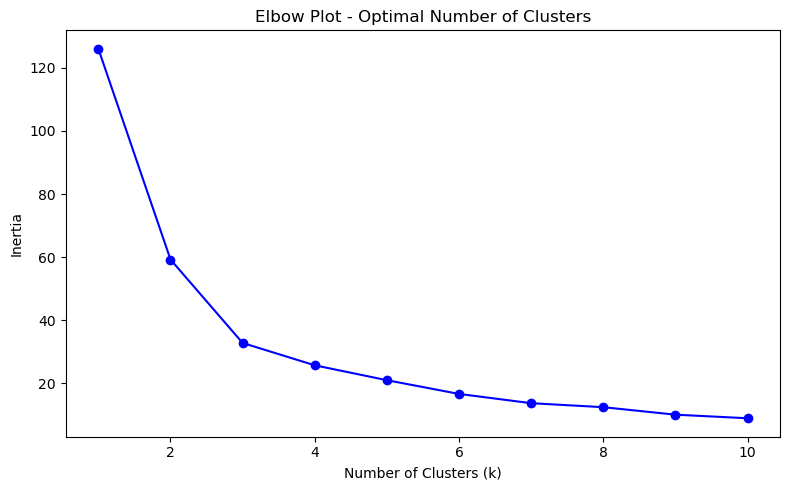

Elbow plot saved!


In [6]:
# elbow plot:
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Plot - Optimal Number of Clusters')
plt.tight_layout()
plt.savefig(viz_path + "cluster_elbow_plot.png", dpi=150)
plt.show()
print("Elbow plot saved!")

In [8]:
# there a strong drop from 1 to 4 which mean I shoudl  group clusters into groups of 4

In [9]:
#Running KMeans with 4 cluster
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster['cluster_label'] = kmeans.fit_predict(df_scaled)

# Give each cluster a meaningful name
cluster_names = {
    0: 'Cluster 0',
    1: 'Cluster 1', 
    2: 'Cluster 2',
    3: 'Cluster 3'
}

df_cluster['cluster_name'] = df_cluster['cluster_label'].map(cluster_names)

print(df_cluster['cluster_label'].value_counts())
print(df_cluster.head())

cluster_label
1    15
2    12
0     8
3     7
Name: count, dtype: int64
  LocationAbbr LocationDesc  diabetes_prevalence  obesity_prevalence  \
0           AK       Alaska             7.616667           31.966667   
1           AL      Alabama            13.766667           38.533333   
2           AR     Arkansas            12.366667           37.833333   
3           AZ      Arizona            10.366667           31.466667   
4           CA   California            10.150000           28.033333   

   inactivity_prevalence  cluster_label cluster_name  
0              21.000000              0    Cluster 0  
1              30.050000              3    Cluster 3  
2              30.033333              3    Cluster 3  
3              22.750000              2    Cluster 2  
4              21.166667              2    Cluster 2  


C:\Users\16124\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [10]:
# Loooking at the average for eac hcluster
cluster_summary = df_cluster.groupby('cluster_label')[
    ['diabetes_prevalence', 'obesity_prevalence', 'inactivity_prevalence']
].mean().round(2)

print(cluster_summary)

               diabetes_prevalence  obesity_prevalence  inactivity_prevalence
cluster_label                                                                
0                             8.02               28.43                  19.72
1                            10.64               34.94                  24.77
2                             9.89               29.38                  23.26
3                            12.93               37.96                  29.90


In [11]:
# assigning names to eac hcluster 
cluster_names = {
    0: 'Low Risk',
    1: 'Moderate Risk',
    2: 'Moderate-Active',
    3: 'High Risk'
}

df_cluster['cluster_name'] = df_cluster['cluster_label'].map(cluster_names)

print(df_cluster[['LocationAbbr', 'LocationDesc', 'cluster_name']].sort_values('cluster_name'))


   LocationAbbr          LocationDesc     cluster_name
1            AL               Alabama        High Risk
2            AR              Arkansas        High Risk
18           LA             Louisiana        High Risk
17           KY              Kentucky        High Risk
36           OK              Oklahoma        High Risk
25           MS           Mississippi        High Risk
40           SC        South Carolina        High Risk
0            AK                Alaska         Low Risk
19           MA         Massachusetts         Low Risk
26           MT               Montana         Low Risk
30           NH         New Hampshire         Low Risk
7            DC  District of Columbia         Low Risk
5            CO              Colorado         Low Risk
37           OR                Oregon         Low Risk
23           MN             Minnesota         Low Risk
29           NE              Nebraska    Moderate Risk
28           ND          North Dakota    Moderate Risk
27        

In [12]:
#Saving the updated file 
df_cluster.to_csv(prepared_path + "cdi_clusters.csv", index=False)

# Also update the main wide file with cluster labels
df_wide = pd.read_csv(prepared_path + "cdi_overall_wide.csv")
df_wide = df_wide.merge(
    df_cluster[['LocationAbbr', 'cluster_label', 'cluster_name']], 
    on='LocationAbbr', 
    how='left'
)

df_wide.to_csv(prepared_path + "cdi_overall_wide.csv", index=False)
print("Files saved! Notebook 05 complete!")

Files saved! Notebook 05 complete!
